# Day 9 — Graph Representation Learning & Node Embeddings

**目标**：把 Lecture 2 的主线真正落到代码：Traditional Feature Engineering → Representation Learning → Encoder/Decoder → Shallow Encoding → Random Walk Similarity → Negative Sampling → Embedding Optimization。

> 今天不是为了“背 DeepWalk/node2vec”，而是理解：**节点为什么需要 embedding、embedding 如何被训练出来、graph similarity 到底由谁定义，以及为什么 shallow embeddings 会自然引出 GNN。**

## 0. Setup

只用 `networkx + torch + matplotlib`，不依赖 PyG。

In [1]:
import random
import math
import networkx as nx
import torch
from torch import nn
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

G = nx.karate_club_graph()
print(G)
print('nodes =', G.number_of_nodes(), 'edges =', G.number_of_edges())

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges
nodes = 34 edges = 78


## 1. Traditional Graph ML：先手工做 feature

传统做法是先人为定义 structured features，再交给学习算法。这里仅做一个 **10 分钟 recap**，不把它当 Day 9 主线。

In [2]:
degree = dict(G.degree())
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)

for u in range(5):
    print(f'node {u}: degree={degree[u]:2d}, clustering={clustering[u]:.3f}, pagerank={pagerank[u]:.4f}')

node 0: degree=16, clustering=0.150, pagerank=0.0885
node 1: degree= 9, clustering=0.333, pagerank=0.0574
node 2: degree=10, clustering=0.244, pagerank=0.0628
node 3: degree= 6, clustering=0.667, pagerank=0.0372
node 4: degree= 3, clustering=0.667, pagerank=0.0205


**必须回答**：如果每换一个任务都要重新决定 degree / centrality / clustering 是否有用，会有什么问题？

你的回答：主要问题是需要针对不同任务反复进行人工 feature engineering，依赖领域经验，难以复用，也可能遗漏真正有用的结构信息

> 

## 2. Node Embedding：把 node 映射到 $\mathbb{R}^d$

目标：$f(u)=z_u\in\mathbb{R}^d$。

注意：embedding 的每一维通常是 **latent feature**，不要求能被人直接命名。

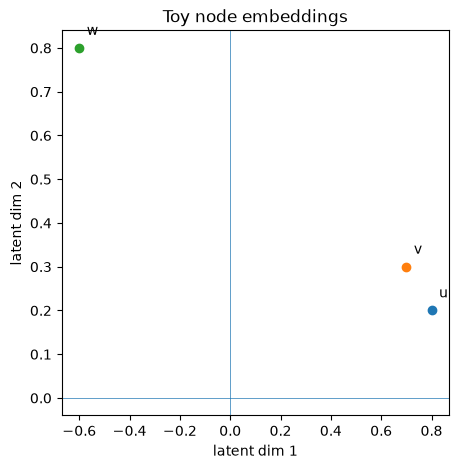

In [3]:
z_u = torch.tensor([0.8, 0.2])
z_v = torch.tensor([0.7, 0.3])
z_w = torch.tensor([-0.6, 0.8])

plt.figure(figsize=(5, 5))
for z, name in [(z_u,'u'), (z_v,'v'), (z_w,'w')]:
    plt.scatter(z[0], z[1])
    plt.text(z[0]+0.03, z[1]+0.03, name)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel('latent dim 1')
plt.ylabel('latent dim 2')
plt.title('Toy node embeddings')
plt.show()

**必须回答**：为什么 `node id = 17` 本身几乎没有语义，而 `z_17 ∈ R^d` 可以携带可学习信息？

node_id = 17 只是节点的唯一索引，本身不包含结构或语义信息；而 z_17 是通过图结构和训练目标学习得到的连续向量，可以编码节点与其他节点的关系、局部结构和潜在语义，因此能够用于分类、聚类、链接预测等下游任务
> 

## 3. Decoder：用 dot product 衡量 embedding similarity

对于列向量 convention，课件写成 $z_v^T z_u$；在 PyTorch 里直接 `torch.dot(z_u, z_v)`。结果是一个 scalar score。

In [4]:
def dot_sim(a, b):
    return torch.dot(a, b).item()

print('sim(u,v) =', dot_sim(z_u, z_v))
print('sim(u,w) =', dot_sim(z_u, z_w))

sim(u,v) = 0.6200000047683716
sim(u,w) = -0.3199999928474426


**必须回答**：`dot product 大` 为什么只能说明 embedding space 里更相似，而不能自动说明原图里更相似？

提示：我们还缺一个东西——**原图里的 similarity 定义**。

> 

## 4. Shallow Encoder：Encoder 只是 Embedding Lookup

Shallow embedding 不根据邻居“算”表示，而是**每个 node 直接拥有一组可学习参数**。这就是课件里的 $Z\in\mathbb{R}^{d\times |V|}$。

PyTorch 中最直观的对应物就是 `nn.Embedding`。

In [5]:
num_nodes = G.number_of_nodes()
embedding_dim = 2
encoder = nn.Embedding(num_nodes, embedding_dim)

node_ids = torch.tensor([0, 1, 2, 3])
z = encoder(node_ids)
print('embedding table shape =', tuple(encoder.weight.shape))
print('selected embeddings shape =', tuple(z.shape))
print(z)

embedding table shape = (34, 2)
selected embeddings shape = (4, 2)
tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047]], grad_fn=<EmbeddingBackward0>)


**必须回答**：这里真正被 optimizer 更新的是 node feature 吗？还是 `encoder.weight`？如果 test time 新来了 node 34，会发生什么？

真正被 optimizer 更新的是 encoder.weight。z 只是从 embedding table 中 lookup 出来的结果。若 test time 出现训练时不存在的新 node 34，当前 nn.Embedding(34, d) 无法直接表示它，需要扩展 embedding table 并重新学习该节点的 embedding，因此 shallow embedding 不具备自然的 inductive 能力。
> 

## 5. Graph Similarity 到底怎么定义？

候选可以很多：

- 直接有 edge
- share neighbors
- structural role 相似
- **random walk 中经常共现 / 从 u 出发经常访问 v**

Lecture 2 接下来选择 random walk 作为 similarity 的来源。

### 5.1 手写 Random Walk

In [17]:
def random_walk(G, start, walk_length=8):
    walk = [start]
    current = start
    for _ in range(walk_length-1):
        nbrs = list(G.neighbors(current))
        current = random.choice(nbrs)
        walk.append(current)
    return walk

for _ in range(5):
    print(random_walk(G, start=0, walk_length=10))

[0, 10, 5, 16, 5, 6, 5, 16, 6, 16]
[0, 21, 0, 8, 2, 1, 17, 0, 8, 33]
[0, 8, 0, 3, 13, 0, 8, 0, 2, 9]
[0, 3, 12, 0, 10, 5, 16, 5, 6, 16]
[0, 8, 32, 22, 32, 8, 0, 19, 1, 19]


### 5.2 从 random walk 生成 positive pairs

如果两个节点在同一条 walk 的局部窗口里共现，就把它们当作 positive pair。这个思路与 NLP 的 word-context 非常接近。

In [21]:
def walk_to_pairs(walk, window_size=2):
    pairs = []
    for i,u in enumerate(walk):
        left = max(0, i-window_size)
        right = min(len(walk), i+window_size+1)
        for j in range(left, right):
            if i != j:
                pairs.append((u, walk[j]))
    return pairs

walk = random_walk(G, 0, 12)
pairs = walk_to_pairs(walk, window_size=2)
print('walk:', walk)
print('first 20 positive pairs:', pairs[:20])

walk: [0, 1, 0, 12, 0, 5, 6, 0, 7, 1, 7, 2]
first 20 positive pairs: [(0, 1), (0, 0), (1, 0), (1, 0), (1, 12), (0, 0), (0, 1), (0, 12), (0, 0), (12, 1), (12, 0), (12, 0), (12, 5), (0, 0), (0, 12), (0, 5), (0, 6), (5, 12), (5, 0), (5, 6)]


**必须回答**：random walk similarity 为什么不仅包含 1-hop 邻居，还可能包含 higher-order / multi-hop 信息？

因为我们要捕捉的可能不只是直接邻居，而是多跳结构关系
> 

## 6. 从 similarity 到训练目标

我们希望：

- positive pair `(u,v)`：$z_u^Tz_v$ 变大
- negative pair `(u,n)`：$z_u^Tz_n$ 变小

下面不完整复刻 DeepWalk/node2vec，而是手搓一个 **最小可懂版本**。

In [23]:
def generate_positive_pairs(G, walks_per_node=3, walk_length=10, window_size=2):
    all_pairs = []
    for u in G:
        for _ in range(walks_per_node):
            walk = random_walk(G, u, walk_length)
            all_pairs.extend(walk_to_pairs(walk, window_size))
    return all_pairs

positive_pairs = generate_positive_pairs(G)
positive_set = set(positive_pairs)
print('num positive pairs =', len(positive_pairs))
print('unique positive pairs =', len(positive_set))

num positive pairs = 3468
unique positive pairs = 548


In [24]:
def sample_negative(u, num_nodes, positive_set):
    while True:
        n = random.randrange(num_nodes)
        if n != u and (u, n) not in positive_set:
            return n

for u, v in positive_pairs[:5]:
    print('positive:', (u,v), 'negative:', (u, sample_negative(u, num_nodes, positive_set)))

positive: (0, 1) negative: (0, 26)
positive: (0, 3) negative: (0, 18)
positive: (1, 0) negative: (1, 20)
positive: (1, 3) negative: (1, 18)
positive: (1, 0) negative: (1, 14)


## 7. 亲手训练一个 2D Shallow Node Embedding

这里的参数就是 embedding table 本身。Loss 使用 `BCEWithLogitsLoss`：positive score 对应标签 1，negative score 对应标签 0。

In [33]:
torch.manual_seed(SEED)
random.seed(SEED)
encoder = nn.Embedding(num_nodes, 2)
optimizer = torch.optim.AdamW(encoder.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def pair_score(u, v):
    zu = encoder(torch.tensor(u))
    zv = encoder(torch.tensor(v))
    return torch.dot(zu, zv)

for epoch in range(200):
    random.shuffle(positive_pairs)
    total_loss = 0.0
    batch_pairs = positive_pairs[:500]

    optimizer.zero_grad()
    logits = []
    labels = []
    for u, v in batch_pairs:
        logits.append(pair_score(u, v))
        labels.append(1.0)
        n = sample_negative(u, num_nodes, positive_set)
        logits.append(pair_score(u, n))
        labels.append(0.0)

    logits = torch.stack(logits)
    labels = torch.tensor(labels)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    if epoch % 40 == 0 or epoch == 199:
        print(f'epoch={epoch:3d} loss={loss.item():.4f}')

epoch=  0 loss=0.8877
epoch= 40 loss=0.9420
epoch= 80 loss=0.8118
epoch=120 loss=0.8199
epoch=160 loss=0.8030
epoch=199 loss=0.7758


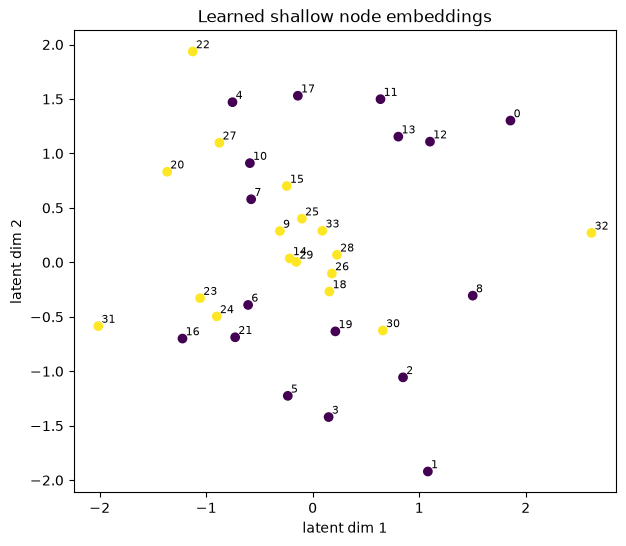

In [34]:
with torch.no_grad():
    Z = encoder.weight.detach().cpu()

club = nx.get_node_attributes(G, 'club')
colors = [0 if club[i] == 'Mr. Hi' else 1 for i in range(num_nodes)]

plt.figure(figsize=(7, 6))
plt.scatter(Z[:,0], Z[:,1], c=colors)
for i in range(num_nodes):
    plt.text(Z[i,0]+0.03, Z[i,1]+0.03, str(i), fontsize=8)
plt.xlabel('latent dim 1')
plt.ylabel('latent dim 2')
plt.title('Learned shallow node embeddings')
plt.show()

**观察问题**：同一 club 的节点是否有一定聚集趋势？如果没有完全分开，也正常——我们的训练目标是 random-walk co-occurrence，不是直接拿 club label 做 supervised classification。

## 8. 为什么要 Negative Sampling？

完整 softmax 若对每个中心节点都和 **所有节点** 做归一化，计算会很贵。Negative sampling 的直觉是：不要每次都和全图比较，只随机抽少量 negative nodes 来做对比。

你现在只需要掌握：

1. positive pair 来自 random walk 共现；
2. negative pair 来自背景分布采样；
3. 训练让 positive score ↑、negative score ↓；
4. 这是一个高效近似/替代目标。

**必须回答**：如果图有 1,000,000 个节点，每个 positive pair 都做全节点 softmax，会发生什么？Negative sampling 为什么会明显便宜？

计算量爆炸；negative sampling便宜在只取出部分负样本来代替全部负样本，极大减少了计算量
> 

## 9. Shallow Embedding 的局限 → 为什么下一天要学 GNN

Shallow encoder 学的是：

```text
node ID -> lookup table -> z_u
```

它没有学一个“根据 feature + neighbors 生成 embedding”的通用函数。所以：

- 新节点没有对应表项；
- 新图也不能直接套；
- 结构角色相似但距离很远的节点，random walk 方法未必能捕获。

下一天进入：

```text
node feature + neighbors
        ↓
AGGREGATE + UPDATE
        ↓
node representation
```

也就是 **Message Passing / GNN as a deep encoder**。

## Day 9 最终自测

不看上面的内容，口头回答：

1. Graph Representation Learning 为什么比 hand-crafted feature engineering 更通用？
2. $f:u\to\mathbb{R}^d$ 表示什么？
3. Encoder、Decoder、Similarity Function 分别是什么？
4. 为什么 shallow encoder = embedding lookup？
5. $z_u^T z_v$ 是什么？为什么它本身不能定义 graph similarity？
6. Random walk 如何给出“哪些节点相似”的监督信号？
7. Positive pair / Negative pair 分别怎么来？
8. Negative sampling 为什么必要？
9. Shallow embedding 为什么是 transductive？
10. 为什么这些局限会自然引出 GNN / Message Passing？